## T7: Timedependent transport through chain using DFT

We now turn to using density-functional theory as implemented in TranSiesta to model the electronic structure of the device and electrodes. The approach we will take is very similar as to how the tight-binding model was used, where we now only have the additional step of converging a TranSiesta calculation. This will be the only additional step we will be concerned with for this tutorial. The DFT part will be a bit more timeconsuming compared to the tight-binding we have used before, as the density have to be solved for selfconsistently. Before we do any calculation, wwe'll have to be certain the atoms we will be inputting to the structures has a pseudo-potential lying in the pp folder in the directory above where you found this tutorial file. You'll of course also have to have Siesta installed, in which the TranSiesta code is found.

The chain we will be considering for this tutorial will be a hydrogen-chain, which of course is not physical, but gives a model containing one site per atom, similarly to what we have done in the tight-binding part of this tutorial. You'll be able to follow the DFT calculation in the folder named "Device" as with any other Siesta calculation.


In [2]:
import matplotlib.pyplot as plt
from Zandpack.TimedependentTransport import TD_Transport
import sisl
import numpy as np
from Zandpack.FittingTools import find_correction

In [3]:
tx        = 12                                # Device tile
elec_tile = 4                                 # Electrode tile
lat_const = 2.5                               # Atoms spacing 
line = np.linspace(-4, 4, 80) + 1j * 1e-2     
line = np.vstack((line, line))                # Energy Sampling

geom_dev = sisl.geom.sc(lat_const, "H").tile(tx + 2 * elec_tile, 0)
geom_ep = (sisl.geom.sc(lat_const, "H")
           .tile(elec_tile, 0)
           .move(np.array([lat_const * (tx + elec_tile), 0, 0])))

geom_em  = sisl.geom.sc(lat_const, "H").tile(elec_tile, 0)
geom_dev = geom_dev.add_vacuum(20, 1).add_vacuum(20, 2).add_vacuum(20, 0)
geom_em  =  geom_em.add_vacuum(20, 1).add_vacuum(20, 2)
geom_ep  =  geom_ep.add_vacuum(20, 1).add_vacuum(20, 2)

Test = TD_Transport([geom_em, geom_ep], 
                     geom_dev, kT_i=[0.025, 0.025])
Test.Make_Contour(line, 20, pole_mode="JieHu2011")
Test.Electrodes(semi_infs=["-a1", "+a1"])
Test.make_device()
Test.run_electrodes()
Test.run_device()
Test.read_data()

/home/investigator/.local/lib/python3.10/site-packages/spglib/spglib.py:115: DeprecationWarning: dict interface (SpglibDataset['std_lattice']) is deprecated.Use attribute interface ({self.__class__.__name__}.{key}) instead
  warnings.warn(
/home/investigator/.local/lib/python3.10/site-packages/spglib/spglib.py:115: DeprecationWarning: dict interface (SpglibDataset['std_positions']) is deprecated.Use attribute interface ({self.__class__.__name__}.{key}) instead
  warnings.warn(
/home/investigator/.local/lib/python3.10/site-packages/spglib/spglib.py:115: DeprecationWarning: dict interface (SpglibDataset['std_types']) is deprecated.Use attribute interface ({self.__class__.__name__}.{key}) instead
  warnings.warn(
/home/investigator/.local/lib/python3.10/site-packages/spglib/spglib.py:115: DeprecationWarning: dict interface (SpglibDataset['number']) is deprecated.Use attribute interface ({self.__class__.__name__}.{key}) instead
  warnings.warn(
/home/investigator/.local/lib/python3.10/site

[[0, 1, 2, 3], [16, 17, 18, 19]]
Running Siesta electrode calculation in Directory: EM!



Job completed


Running Siesta electrode calculation in Directory: EP!



Job completed


...

Running Siesta-analyse in Directory:Device!



Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG IEEE_DENORMAL


Running TB-Trans in Directory: Device!



dep:0: SislDeprecation: tbtncSileTBtrans.geom is deprecated, please use '.geometry'.0.14 [>=0.16]


Calculating corrections for electrode 0. (Normal electrode)
Calculating corrections for electrode 1. (Normal electrode)

 Building ES - H - Self Energies 

[0]
Using S = S

 Overlap Included!



In [87]:
Test.reset_all_fits()
Eg = np.linspace(-5,5,300)
NL = 31
E  = np.linspace(-2, 2.4, NL)
number   = 0.15
G1       = np.ones(NL)[None,:]*number
init_G   = [G1,G1]
init_E   = [E[None,:], E[None,:]]
alpha_PO = 0.001
min_tol  = np.ones((1,NL))*-.0
min_tol1, min_tol2 = min_tol.copy(),min_tol.copy()
# In[]
def run_mini(its,method, elecs = None):
    Test.Fit(fact = 0.6,                            # Redundant when we give init_E and init_G
          Fallback_W = 5.0,                    # Redundant\n",
          NumL = NL,                           # Not redundant\n",
          fit_mode = 'all',                    # Important to choose mode\n",
          force_PSD     = True,                # the self-energies are not positive semidefinite
          force_PSD_tol = [min_tol1,
                           min_tol2], # 
          use_analytical_jac = False,           # Important for speed
          min_method = method,                # Choose from any scipy.optimize.minimize method
          ebounds = (-2.5,2.5),                # bounds on centres
          wbounds = (0.001, 3),                # bounds on widths
          gbounds = (None, None),              # bounds on sizes, redundant right now
          tol = 1e-5,                         # any negative value with mean we fit all matrix elements of \\Gamma
          options = {'disp':True,              # Minimizer options
                     'maxiter':its, 
                     'gtol':1e-10, 
                     #'iprint':1,
                     }, 
          fit_real_part = False,              # 
          alpha_PO = alpha_PO,                # Repulsion
          init_E = init_E,                    # Give initial ei's and gi's
          init_G = init_G,
          which_e = elecs
          )
    C = find_correction(Test)
    # Test.Renormalise_H(C)
run_mini(0,'SLSQP')
Test.curvefit_all(0.01)
if True:
    Test.NO_fitted_lorentzians[0].iterative_PSD(
        maxit=41, n=40,nW=15,
        lbtol= -0.001,fact=.5,
        add_last = False, )
    Test.NO_fitted_lorentzians[1].iterative_PSD(
        maxit=41, n=40,nW=15,
        lbtol= -0.001,fact=.5,
        add_last = False)
Test.FitNO2O()
#Test.diagonalise()
#Test.get_propagation_quantities()
#Test.get_dense_matrices_purenp()


Finding Lambda matrices:
False

--------------------
Optimizing Lorentzian Expansion
--------------------

2
#Variables optimized for: 62
Iteration limit reached    (Exit mode 9)
            Current function value: 0.3903190097841257
            Iterations: 1
            Function evaluations: 63
            Gradient evaluations: 1
Lorentzian fit took 0.07983231544494629 seconds.
Finding Lambda matrices:
False

--------------------
Optimizing Lorentzian Expansion
--------------------

3
#Variables optimized for: 62
Iteration limit reached    (Exit mode 9)
            Current function value: 0.39035700283567054
            Iterations: 1
            Function evaluations: 63
            Gradient evaluations: 1
Lorentzian fit took 0.08656096458435059 seconds.


100%|██████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 366.76it/s]

Refining eigenvalues of Fit!
refinement pass 0,  minimum eigenvalue:  -0.03848984212409423
it, mineigv:  4 -0.0005423295156978887
Refining eigenvalues of Fit!
refinement pass 0,  minimum eigenvalue:  -0.038504670466016085
it, mineigv:  4 -0.0005426023913760746


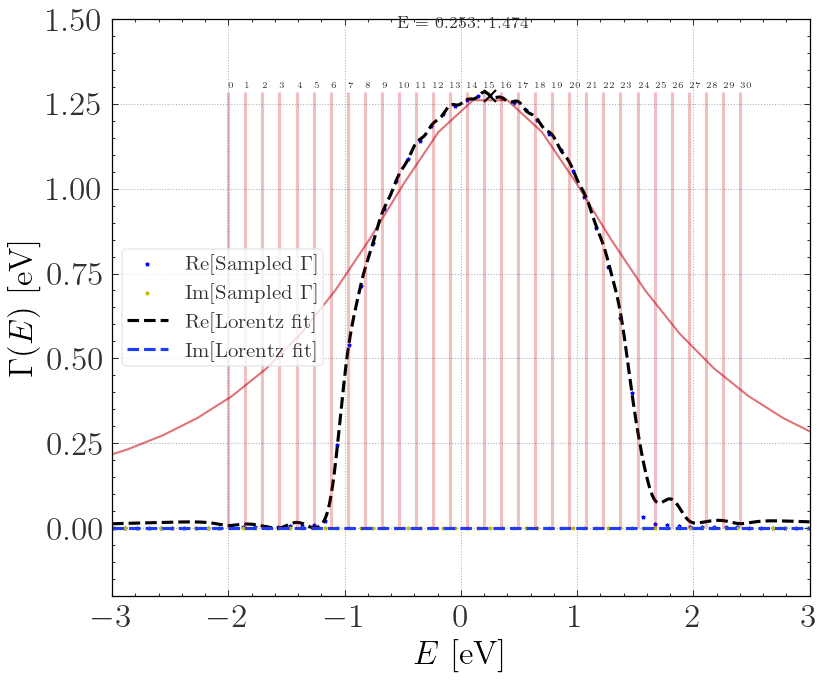

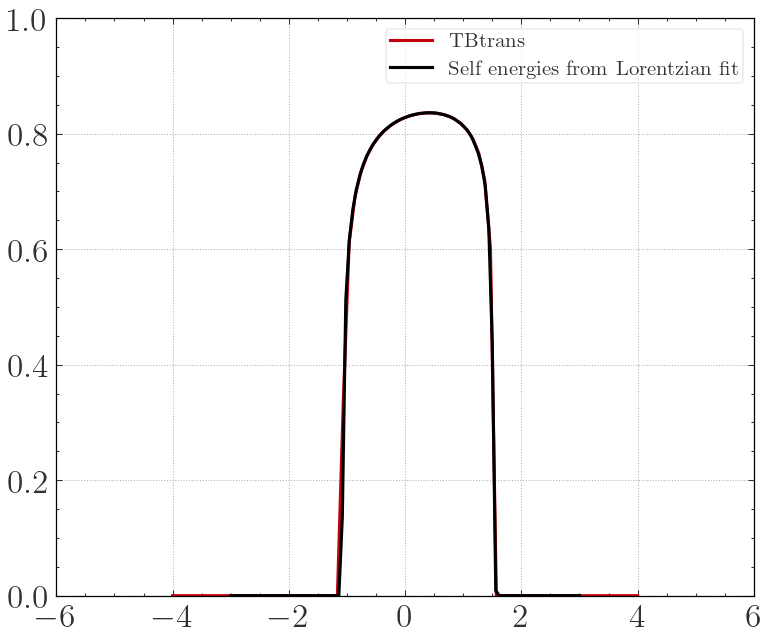

In [88]:
Test.Inspect_Lorentzian_fit(0, 0, 0, 0, 0, Emin = -3, Emax = 3,n_samples=1000, center_lines=True)
plt.xlim(-3,3);plt.ylim(-.2, 1.5); plt.show()
Test.Inspect_transmission_from_hilbert_transform(E=np.linspace(-3,3,101),eta=1e-2)

So far so good! The approach is very similar to what we have done with tight-binding, and in some ways also simpler, as we dont have to input electrode indices, which are found automatically (if we have build the structure correctly). We only have to wait a bit longer for the TranSiesta code to do its thing, whereafter it is business-as-usual with TBtrans and fitting. A thing to note is that the self energy plotted in the figure above is now a bit assymetric around $E=\mu=0$eV which comes from the slight overlap now present between the orbitals. We now, however, have the full power of the TranSiesta code the obtain the electronic structure of the device region. A thing to note is that the fitting in the Lorentzians only scales with the number of the Lorentzians used, not the number of matrix-entries, because the weights on each $\mathbf{\Lambda}_{\alpha l}$ Lorentzian can be found by a matrix inversion when the poles of the Lorentzians are given. 



####  Your task is now to go ahead and do just as we have done previously and propagate the system in time:
    1. Copy some code from the tight-binding tutorial and get the density and current running through the system to stabilize and go to zero respectively. 
    2. Now, used the stabilised system as a starting point for the case were a pulse is going through the system. Use e.g. a square pulse from the "Pulses" module. 

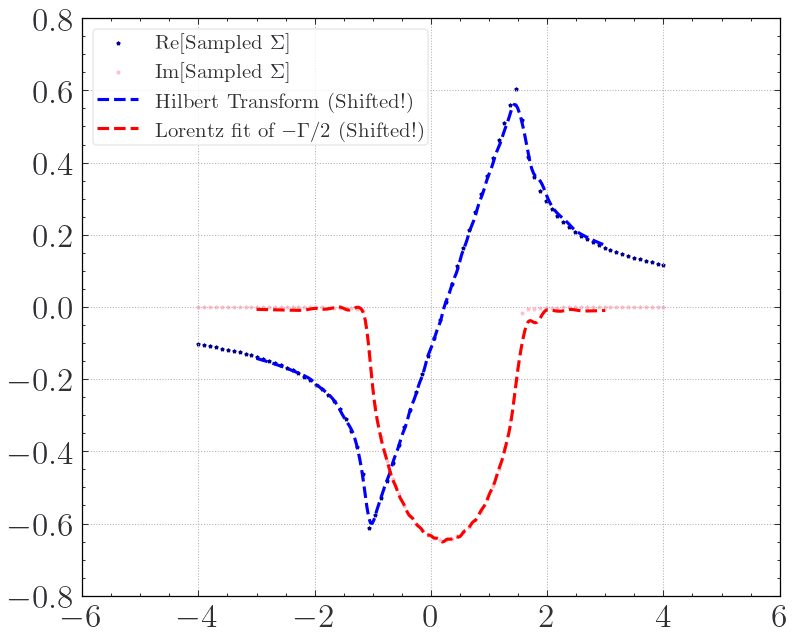

In [89]:
Test.Inspect_SE_from_hilbert_transform(0,0,0,0,0)